<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDS0321ENSkillsNetwork26802033-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **Space X  Falcon 9 First Stage Landing Prediction**


## Hands on Lab: Complete the Machine Learning Prediction lab


Estimated time needed: **60** minutes


Space X advertises Falcon 9 rocket launches on its website with a cost of 62 million dollars; other providers cost upward of 165 million dollars each, much of the savings is because Space X can reuse the first stage. Therefore if we can determine if the first stage will land, we can determine the cost of a launch. This information can be used if an alternate company wants to bid against space X for a rocket launch.   In this lab, you will create a machine learning pipeline  to predict if the first stage will land given the data from the preceding labs.


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/landing_1.gif)


Several examples of an unsuccessful landing are shown here:


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/crash.gif)


Most unsuccessful landings are planed. Space X; performs a controlled landing in the oceans.


## Objectives


Perform exploratory  Data Analysis and determine Training Labels

*   create a column for the class
*   Standardize the data
*   Split into training data and test data

\-Find best Hyperparameter for SVM, Classification Trees and Logistic Regression

*   Find the method performs best using test data


## Import Libraries and Define Auxiliary Functions


We will import the following libraries for the lab


In [2]:
# Pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
# NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns
# Preprocessing allows us to standarsize our data
from sklearn import preprocessing
# Allows us to split our data into training and testing data
from sklearn.model_selection import train_test_split
# Allows us to test parameters of classification algorithms and find the best one
from sklearn.model_selection import GridSearchCV
# Dummy classifier
from sklearn.dummy import DummyClassifier
# Logistic Regression classification algorithm
from sklearn.linear_model import LogisticRegression
# Support Vector Machine classification algorithm
from sklearn.svm import SVC
# Decision Tree classification algorithm
from sklearn.tree import DecisionTreeClassifier
# K Nearest Neighbors classification algorithm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report

This function is to plot the confusion matrix.


In [3]:
def plot_confusion_matrix(y,y_predict):
    "this function plots the confusion matrix"

    cm = confusion_matrix(y, y_predict)
    ax= plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix'); 
    ax.xaxis.set_ticklabels(['did not land', 'land']); ax.yaxis.set_ticklabels(['did not land', 'landed']) 
    plt.show() 

## Load the dataframe


We will load two datasets, and then merge them on the FlightNumber feature in each. This way we can be assured that the flights match with the correct flight data, and the outcome.

First load the flight metadata, including the outcomes. We only need the FlightNumber and the outcome (Class).


In [4]:
URL1 = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
flight_metadata = pd.read_csv(URL1)
flight_metadata = flight_metadata[['FlightNumber', 'Class']]
flight_metadata.head()

,FlightNumber,Class
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


We can see the distribution of the target class, what we want to predict.

In [5]:
flight_metadata['Class'].value_counts()

Class
1    60
0    30
Name: count, dtype: int64

How much does flight number correlate with higher probability with failure? Early on the development program, there were few successful landings (4/19). Beginning with flight 20, it has become more reliable. Since FlightNumber can skew the model, we will drop it ultimately from the feautres it is trained on.

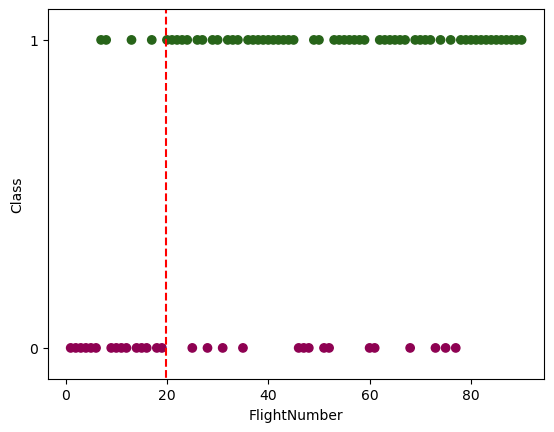

In [63]:
plt.scatter(flight_metadata['FlightNumber'], flight_metadata['Class'], c=flight_metadata['Class'], cmap="PiYG")
plt.vlines(19.9, -0.5, 1.5, color='red', linestyles="dashed")
plt.ylabel('Class')
plt.xlabel('FlightNumber')
plt.yticks([0, 1])
plt.ylim(-.1, 1.1)
plt.savefig('flight_number_vs_class.jpg')
plt.show()

Next, we will load the flight data

In [7]:
URL2 = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv'
flight_data = pd.read_csv(URL2)
flight_data['FlightNumber'] = flight_data['FlightNumber'].astype(int)
flight_data.head()

,FlightNumber,PayloadMass,Flights,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,...,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062,GridFins_False,GridFins_True,Reused_False,Reused_True,Legs_False,Legs_True
0,1,6104.959412,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,2,525.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,3,677.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,4,500.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,5,3170.000000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0


We will then merge them, on the FlightNumber feature. 

In [8]:
data = pd.merge(flight_data, flight_metadata, on='FlightNumber')
data.head()


,FlightNumber,PayloadMass,Flights,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,...,Serial_B1059,Serial_B1060,Serial_B1062,GridFins_False,GridFins_True,Reused_False,Reused_True,Legs_False,Legs_True,Class
0,1,6104.959412,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0
1,2,525.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0
2,3,677.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0
3,4,500.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0
4,5,3170.000000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0


## TASK  1


Split the data into X and y sets, as dataframes and series respectively.


In [9]:
y = data['Class']
print(y.head(10))

X = data.drop(columns=['FlightNumber', 'Class'])
X.head()

0    0
1    0
2    0
3    0
4    0
5    0
6    1
7    1
8    0
9    0
Name: Class, dtype: int64


,PayloadMass,Flights,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,Orbit_LEO,...,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062,GridFins_False,GridFins_True,Reused_False,Reused_True,Legs_False,Legs_True
0,6104.959412,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,525.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,677.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,500.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,3170.000000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0


## TASK  2


Standardize the data in <code>X</code> then reassign it to the variable  <code>X</code> using the transform provided below.


In [10]:
# students get this 
transform = preprocessing.StandardScaler()



Scaling the entire dataset before splitting it is **not** correct procedure. We will follow correct practice below. 

1) Split into test and train
2) Fit the scaler only on the **train set**
3) Transform on the **train set** (2 & 3 can be combined with fit_transform() method)
4) Transform on the **test set**

For one thing, our test set is a simulation of the new data our model will be deployed to perform inference on. And we will **never** be re-training the scaler on that data!

We split the data into training and testing data using the  function  <code>train_test_split</code>.   The training data is divided into validation data, a second set used for training  data; then the models are trained and hyperparameters are selected using the function <code>GridSearchCV</code>.


## TASK  3


Use the function train_test_split to split the data X and Y into training and test data. Set the parameter test_size to  0.2 and random_state to 2. The training data and test data should be assigned to the following labels.


<code>X_train, X_test, Y_train, Y_test</code>


we can see we only have 18 test samples.


We will then separate out the continuous values: fit the scaler on them in training data, transform them, and then transform the test set continuous values. We **do not** need to scale one hot encoded values!

np.hstack will reorganize the data sets concatenating the scaled continuous values with the one-hot encoded categorical features (using Numpy rather than Pandas). In the process we are transforming the train and test sets from Pandas dataframes to Numpy arrays.

This is an option: we can also submit Pandas Dataframes to our models just as well.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale only numerical columns
X_train_scaled = transform.fit_transform(X_train[['PayloadMass', 'Flights', 'Block', 'ReusedCount']])
X_train_scaled = np.hstack((X_train_scaled, X_train.iloc[:, 4:].to_numpy()))

X_test_scaled = transform.transform(X_test[['PayloadMass', 'Flights', 'Block', 'ReusedCount']])
X_test_scaled = np.hstack((X_test_scaled, X_test.iloc[:, 4:].to_numpy()))




### Accumulate results

In [12]:
from sklearn.metrics import f1_score

results = []
def add_results(model, train_accuracy, test_accuracy, f1_score):
    result = {
        'model': model,
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'f1_score': f1_score
    }
    results.append(result)

## Make a baseline

A very nice way to establish a baseline is how well can we predict the outcome at random, or, in this case, if we just predict always a succesful landing. Since we have more successes than failures (roughly 2:1), we can predict success with 67% accuracy. Which is not a *terrible* model, a little better than guessing (50%), but misleading!

Once we have a baseline, our first task is to beat it with an actual model.

In [13]:
dummy_clf = DummyClassifier(strategy='most_frequent')
dummy_clf.fit(X_train_scaled, y_train)
dummy_pred = dummy_clf.predict(X_test_scaled)
print(classification_report(y_test, dummy_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.78      1.00      0.88        14

    accuracy                           0.78        18
   macro avg       0.39      0.50      0.44        18
weighted avg       0.60      0.78      0.68        18



c:\Users\karen\Anaconda3\envs\2u-data\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\karen\Anaconda3\envs\2u-data\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\karen\Anaconda3\envs\2u-data\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

In [14]:
add_results(
    "Baseline",
    dummy_clf.score(X_train, y_train),
    dummy_clf.score(X_test, y_test),
    f1_score(y_test, dummy_pred)
)

## TASK  4


Create a logistic regression object  then create a  GridSearchCV object  <code>logreg_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [15]:
parameters ={'C':[0.01,0.1,1],
             'penalty':['l2'],
             'solver':['lbfgs']}

In [16]:
parameters ={"C":[0.01,0.1,1],'penalty':['l2'], 'solver':['lbfgs']}# l1 lasso l2 ridge
lr=LogisticRegression()

logreg_cv = GridSearchCV(lr, parameters, cv=10, verbose=5, n_jobs=-1, scoring='balanced_accuracy')
logreg_cv.fit(X_train_scaled, y_train)

Fitting 10 folds for each of 3 candidates, totalling 30 fits


,estimator,LogisticRegression()
,param_grid,"{'C': [0.01, 0.1, ...], 'penalty': ['l2'], 'solver': ['lbfgs']}"
,scoring,'balanced_accuracy'
,n_jobs,-1
,refit,True
,cv,10
,verbose,5
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


We output the <code>GridSearchCV</code> object for logistic regression. We display the best parameters using the data attribute <code>best_params\_</code> and the accuracy on the validation data using the data attribute <code>best_score\_</code>.


In [17]:
print("tuned hpyerparameters :(best parameters) ",logreg_cv.best_params_)
print("accuracy :",logreg_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
accuracy : 0.7866666666666666


In [18]:
pd.DataFrame(logreg_cv.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_penalty,param_solver,params,split0_test_score,split1_test_score,...,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.004301,0.001554,0.002500,0.000805,0.01,l2,lbfgs,"{'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}",0.500000,0.5,...,0.5,0.50,0.50,0.500000,0.500000,0.500000,0.5,0.500000,0.000000,3
1,0.003624,0.000845,0.001876,0.000539,0.10,l2,lbfgs,"{'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}",0.666667,0.9,...,0.9,0.50,0.75,0.833333,0.500000,0.833333,1.0,0.728333,0.192650,2
2,0.004401,0.000490,0.002199,0.000980,1.00,l2,lbfgs,"{'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}",0.833333,0.9,...,0.9,0.75,0.75,0.833333,0.666667,0.833333,1.0,0.786667,0.156312,1


## TASK  5


Calculate the accuracy on the test data using the method <code>score</code>:


In [19]:
logreg_cv.score(X_test_scaled, y_test)

0.875

Lets look at the confusion matrix:


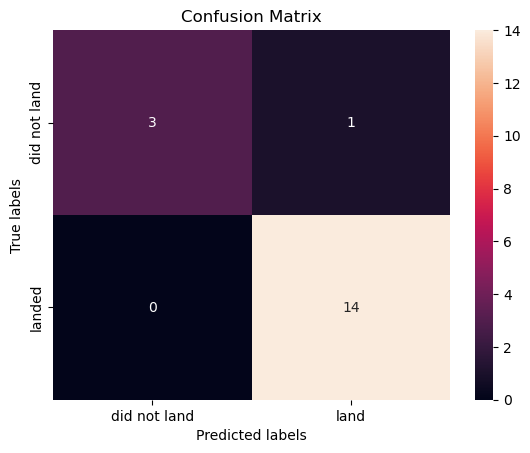

              precision    recall  f1-score   support

           0       1.00      0.75      0.86         4
           1       0.93      1.00      0.97        14

    accuracy                           0.94        18
   macro avg       0.97      0.88      0.91        18
weighted avg       0.95      0.94      0.94        18



In [20]:
yhat = logreg_cv.predict(X_test_scaled)
plot_confusion_matrix(y_test, yhat)
print(classification_report(y_test, yhat))

In [21]:
add_results(
    "Logistic Regression",
    logreg_cv.score(X_train_scaled, y_train),
    logreg_cv.score(X_test_scaled, y_test),
    f1_score(y_test, yhat)
)

Examining the confusion matrix, we see that logistic regression can distinguish between the different classes.  We see that the problem is false positives.

Overview:

True Postive - 12 (True label is landed, Predicted label is also landed)

False Postive - 3 (True label is not landed, Predicted label is landed)


## TASK  6


Create a support vector machine object then  create a  <code>GridSearchCV</code> object  <code>svm_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [22]:
parameters = {'kernel':('linear', 'rbf','poly','rbf', 'sigmoid'),
              'C': np.logspace(-3, 3, 5),
              'gamma':np.logspace(-3, 3, 5)}
svm = SVC()

svm_cv = GridSearchCV(svm, parameters, n_jobs=-1, verbose=3, cv=10)
svm_cv.fit(X_train_scaled, y_train)

Fitting 10 folds for each of 125 candidates, totalling 1250 fits


,estimator,SVC()
,param_grid,"{'C': array([1.0000...00000000e+03]), 'gamma': array([1.0000...00000000e+03]), 'kernel': ('linear', ...)}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,10
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,np.float64(31.622776601683793)


In [23]:
print("tuned hpyerparameters :(best parameters) ",svm_cv.best_params_)
print("accuracy :",svm_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'C': np.float64(31.622776601683793), 'gamma': np.float64(0.03162277660168379), 'kernel': 'sigmoid'}
accuracy : 0.8178571428571427


In [24]:
pd.DataFrame(svm_cv.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_gamma,param_kernel,params,split0_test_score,split1_test_score,...,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.046698,0.053954,0.001300,0.000641,0.001,0.001,linear,"{'C': 0.001, 'gamma': 0.001, 'kernel': 'linear'}",0.625,0.625,...,0.714286,0.714286,0.714286,0.571429,0.571429,0.571429,0.571429,0.639286,0.064286,65
1,0.004800,0.005946,0.001501,0.000922,0.001,0.001,rbf,"{'C': 0.001, 'gamma': 0.001, 'kernel': 'rbf'}",0.625,0.625,...,0.714286,0.714286,0.714286,0.571429,0.571429,0.571429,0.571429,0.639286,0.064286,65
2,0.001707,0.000463,0.001093,0.000303,0.001,0.001,poly,"{'C': 0.001, 'gamma': 0.001, 'kernel': 'poly'}",0.625,0.625,...,0.714286,0.714286,0.714286,0.571429,0.571429,0.571429,0.571429,0.639286,0.064286,65
3,0.002799,0.002856,0.001700,0.001187,0.001,0.001,rbf,"{'C': 0.001, 'gamma': 0.001, 'kernel': 'rbf'}",0.625,0.625,...,0.714286,0.714286,0.714286,0.571429,0.571429,0.571429,0.571429,0.639286,0.064286,65
4,0.002599,0.001855,0.001300,0.000781,0.001,0.001,sigmoid,"{'C': 0.001, 'gamma': 0.001, 'kernel': 'sigmoid'}",0.625,0.625,...,0.714286,0.714286,0.714286,0.571429,0.571429,0.571429,0.571429,0.639286,0.064286,65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,0.001799,0.000748,0.001410,0.000913,1000.000,1000.000,linear,"{'C': 1000.0, 'gamma': 1000.0, 'kernel': 'line...",0.875,0.750,...,0.571429,0.857143,0.857143,0.571429,0.714286,0.857143,1.000000,0.791071,0.131235,13
121,0.003390,0.004276,0.001318,0.000450,1000.000,1000.000,rbf,"{'C': 1000.0, 'gamma': 1000.0, 'kernel': 'rbf'}",0.625,0.625,...,0.714286,0.714286,0.714286,0.571429,0.571429,0.571429,0.571429,0.639286,0.064286,65
122,0.002991,0.002724,0.001310,0.000637,1000.000,1000.000,poly,"{'C': 1000.0, 'gamma': 1000.0, 'kernel': 'poly'}",0.875,0.750,...,0.571429,0.857143,0.714286,0.857143,0.714286,0.714286,1.000000,0.776786,0.114411,24
123,0.001901,0.000300,0.001300,0.000459,1000.000,1000.000,rbf,"{'C': 1000.0, 'gamma': 1000.0, 'kernel': 'rbf'}",0.625,0.625,...,0.714286,0.714286,0.714286,0.571429,0.571429,0.571429,0.571429,0.639286,0.064286,65


## TASK  7


Calculate the accuracy on the test data using the method <code>score</code>:


In [25]:
svm_cv.score(X_test_scaled, y_test)

0.8333333333333334

We can plot the confusion matrix


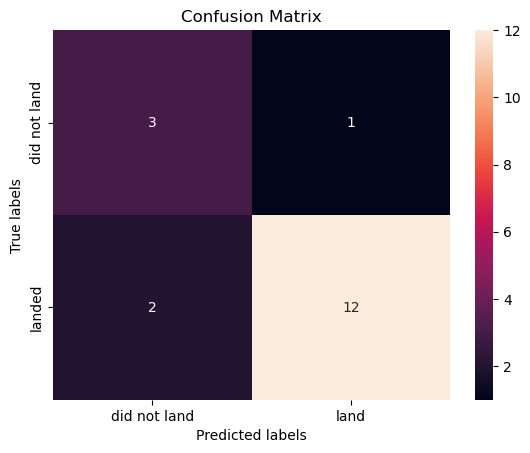

              precision    recall  f1-score   support

           0       0.60      0.75      0.67         4
           1       0.92      0.86      0.89        14

    accuracy                           0.83        18
   macro avg       0.76      0.80      0.78        18
weighted avg       0.85      0.83      0.84        18



In [26]:
yhat=svm_cv.predict(X_test_scaled)
plot_confusion_matrix(y_test, yhat)
print(classification_report(y_test, yhat))

In [27]:
add_results(
    "SVM",
    svm_cv.score(X_train_scaled, y_train),
    svm_cv.score(X_test_scaled, y_test),
    f1_score(y_test, yhat)
)

## TASK  8


Create a decision tree classifier object then  create a  <code>GridSearchCV</code> object  <code>tree_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [28]:
parameters = {'criterion': ['gini', 'entropy'],
     'splitter': ['best', 'random'],
     'max_depth': [2*n for n in range(1,10)],
     'max_features': ['sqrt', 'log2', None],
     'min_samples_leaf': [1, 2, 4],
     'min_samples_split': [2, 5, 10]}

tree = DecisionTreeClassifier()
tree_cv = GridSearchCV(tree, parameters, n_jobs=-1, cv=5, verbose=2)
tree_cv.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 972 candidates, totalling 4860 fits


,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [2, 4, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], ...}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [29]:
print("tuned hpyerparameters :(best parameters) ",tree_cv.best_params_)
print("accuracy :",tree_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'criterion': 'gini', 'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'splitter': 'best'}
accuracy : 0.8761904761904763


## TASK  9


Calculate the accuracy of tree_cv on the test data using the method <code>score</code>:


In [30]:
tree_cv.score(X_test_scaled, y_test)

0.8888888888888888

We can plot the confusion matrix


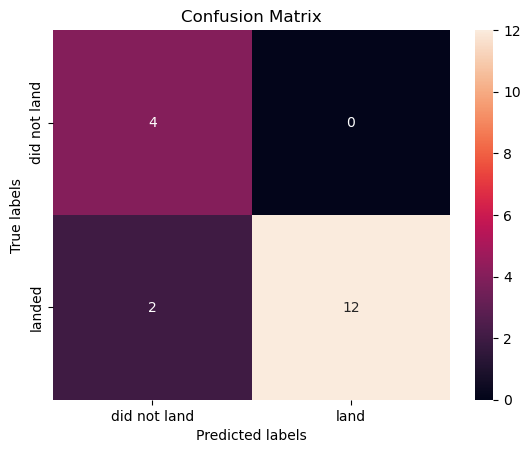

              precision    recall  f1-score   support

           0       0.67      1.00      0.80         4
           1       1.00      0.86      0.92        14

    accuracy                           0.89        18
   macro avg       0.83      0.93      0.86        18
weighted avg       0.93      0.89      0.90        18



In [31]:
yhat = tree_cv.predict(X_test_scaled)
plot_confusion_matrix(y_test,yhat)
print(classification_report(y_test, yhat))

In [32]:
add_results(
    "Decision Tree",
    tree_cv.score(X_train_scaled, y_train),
    tree_cv.score(X_test_scaled, y_test),
    f1_score(y_test, yhat)
)

## TASK  10


Create a k nearest neighbors object then  create a  <code>GridSearchCV</code> object  <code>knn_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [33]:
parameters = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'p': [1,2]}

KNN = KNeighborsClassifier()

In [34]:
knn_cv = GridSearchCV(KNN, parameters, cv=10, n_jobs=-1, verbose=4)
knn_cv.fit(X_train_scaled, y_train)

Fitting 10 folds for each of 80 candidates, totalling 800 fits


,estimator,KNeighborsClassifier()
,param_grid,"{'algorithm': ['auto', 'ball_tree', ...], 'n_neighbors': [1, 2, ...], 'p': [1, 2]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,10
,verbose,4
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,9


In [35]:
print("tuned hpyerparameters :(best parameters) ",knn_cv.best_params_)
print("accuracy :",knn_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'algorithm': 'auto', 'n_neighbors': 9, 'p': 1}
accuracy : 0.8178571428571427


## TASK  11


Calculate the accuracy of knn_cv on the test data using the method <code>score</code>:


In [36]:
knn_cv.score(X_test_scaled, y_test)

0.9444444444444444

We can plot the confusion matrix


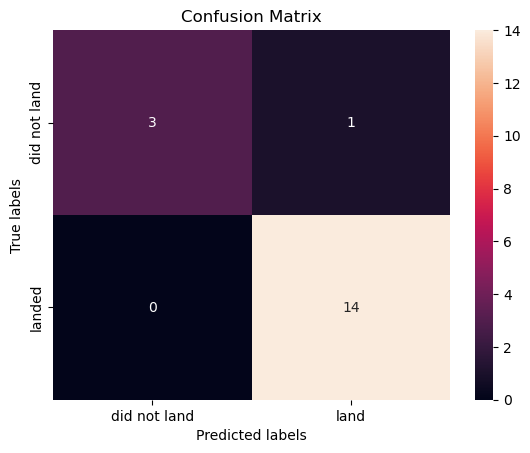

              precision    recall  f1-score   support

           0       1.00      0.75      0.86         4
           1       0.93      1.00      0.97        14

    accuracy                           0.94        18
   macro avg       0.97      0.88      0.91        18
weighted avg       0.95      0.94      0.94        18



In [37]:
yhat = knn_cv.predict(X_test_scaled)
plot_confusion_matrix(y_test,yhat)
print(classification_report(y_test, yhat))

In [38]:
add_results(
    "KNN",
    knn_cv.score(X_train_scaled, y_train),
    knn_cv.score(X_test_scaled, y_test),
    f1_score(y_test, yhat)
)

## TASK  12


Find the method performs best:


In [39]:
pd.DataFrame(results)

,model,train_accuracy,test_accuracy,f1_score
0,Baseline,0.638889,0.777778,0.875000
1,Logistic Regression,0.882107,0.875000,0.965517
2,SVM,0.944444,0.833333,0.888889
3,Decision Tree,0.902778,0.888889,0.923077
4,KNN,0.819444,0.944444,0.965517


## Authors


[Pratiksha Verma](https://www.linkedin.com/in/pratiksha-verma-6487561b1/)


<!--## Change Log--!>


<!--| Date (YYYY-MM-DD) | Version | Changed By      | Change Description      |
| ----------------- | ------- | -------------   | ----------------------- |
| 2022-11-09        | 1.0     | Pratiksha Verma | Converted initial version to Jupyterlite|--!>


### <h3 align="center"> IBM Corporation 2022. All rights reserved. <h3/>
